# Latent Space Decision Boundaries & Adversarial Trajectory

This notebook visualizes the neural network's decision boundaries projected onto a 2D PCA plane, overlaid with the trajectory of a Targeted I-FGSM attack.

To achieve this, we create a 2D meshgrid over the PCA space, apply the inverse PCA transformation to project these points back into the high-dimensional latent space, and feed them through the CNN's final classification layer. This reveals the "territories" of different classes in the embedding space and perfectly illustrates how the adversarial attack navigates from the original class region, through intermediate boundaries, into the target class region.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

# Import models
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2

# Import specific preprocessing and decoding functions
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob

In [2]:
# Dictionary with model configurations
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_mob,
        'clip_min': -1.0,
        'clip_max': 1.0,
        'eps_scale': 1.0
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_eff,
        'clip_min': 0.0,
        'clip_max': 255.0,
        'eps_scale': 127.5
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299),
        'preprocess_fn': preprocess_inc,
        'clip_min': -1.0,
        'clip_max': 1.0,
        'eps_scale': 1.0
    }
}

# Freeze weights as we only need to perform inference and compute gradients w.r.t inputs
for config in models_dict.values():
    config['model'].trainable = False

# Dictionary for target images
images_dict = {
    'Dog': '../images/dog.png',
    'Lion': '../images/lion.png'
}

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img) # Dynamic preprocessing
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

In [4]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

# Custom colormap for the background (0: Other classes [Gray], 1: Original Class [Blue], 2: Target Class [Red])
cmap_background = ListedColormap(['#E0E0E0', '#D0E0FF', '#FFD0D0'])


COMPUTING DECISION BOUNDARIES: MobileNetV2

--- Processing Image: Dog ---


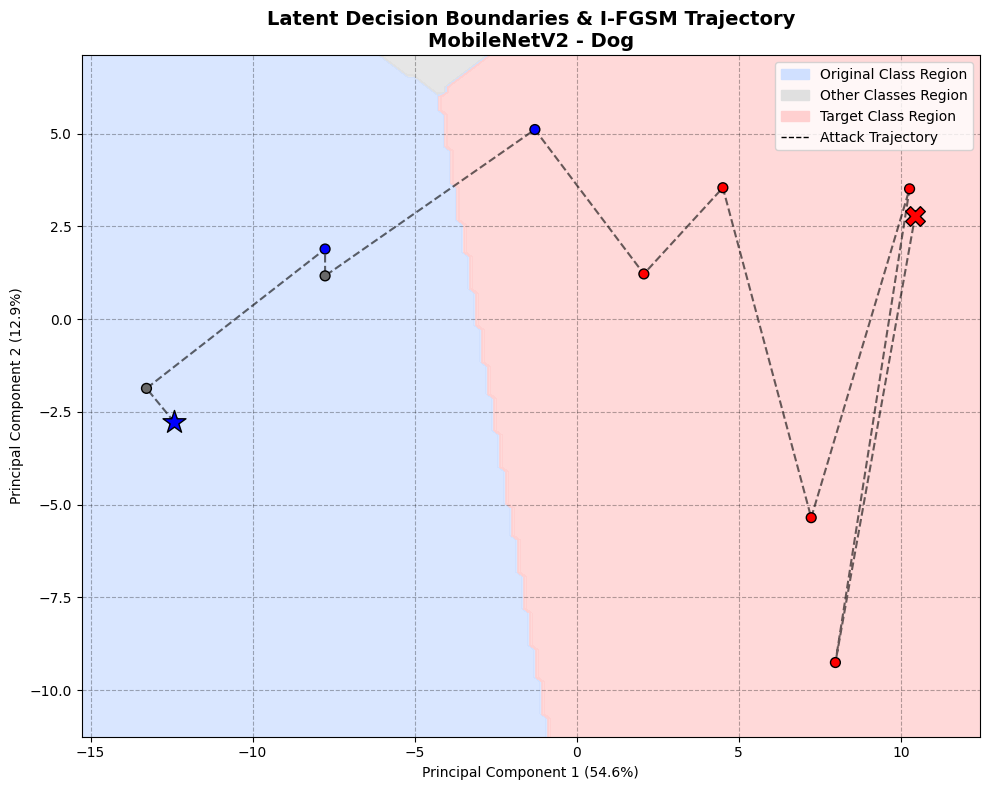

--- Processing Image: Lion ---


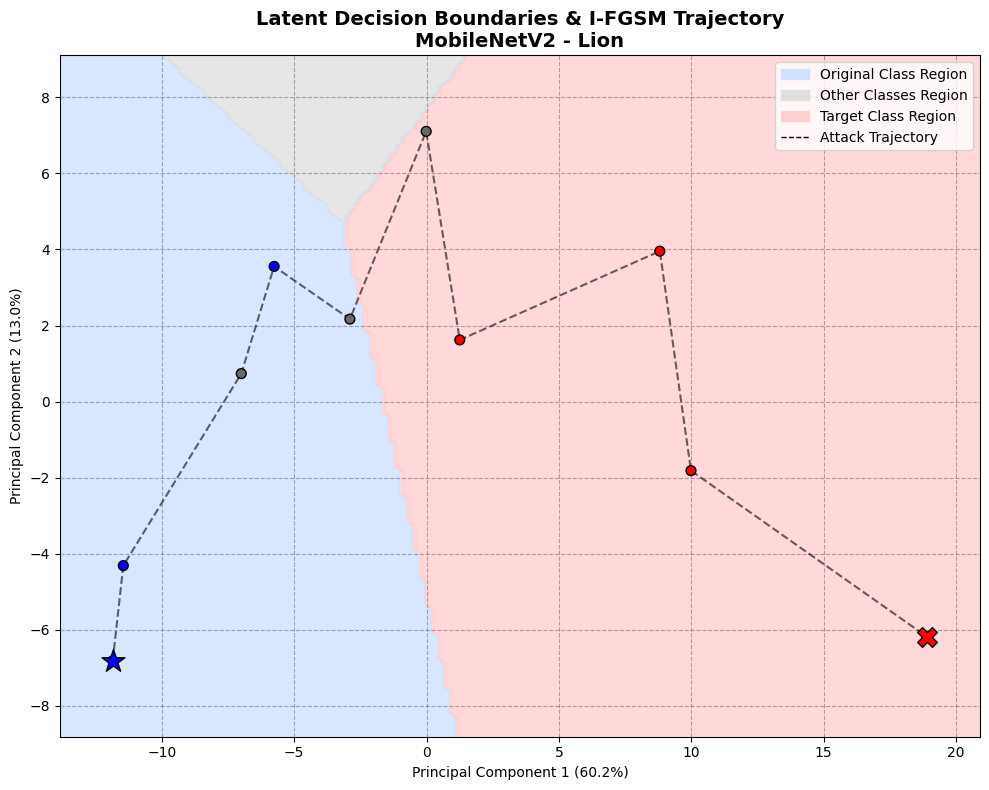


COMPUTING DECISION BOUNDARIES: EfficientNetB0

--- Processing Image: Dog ---


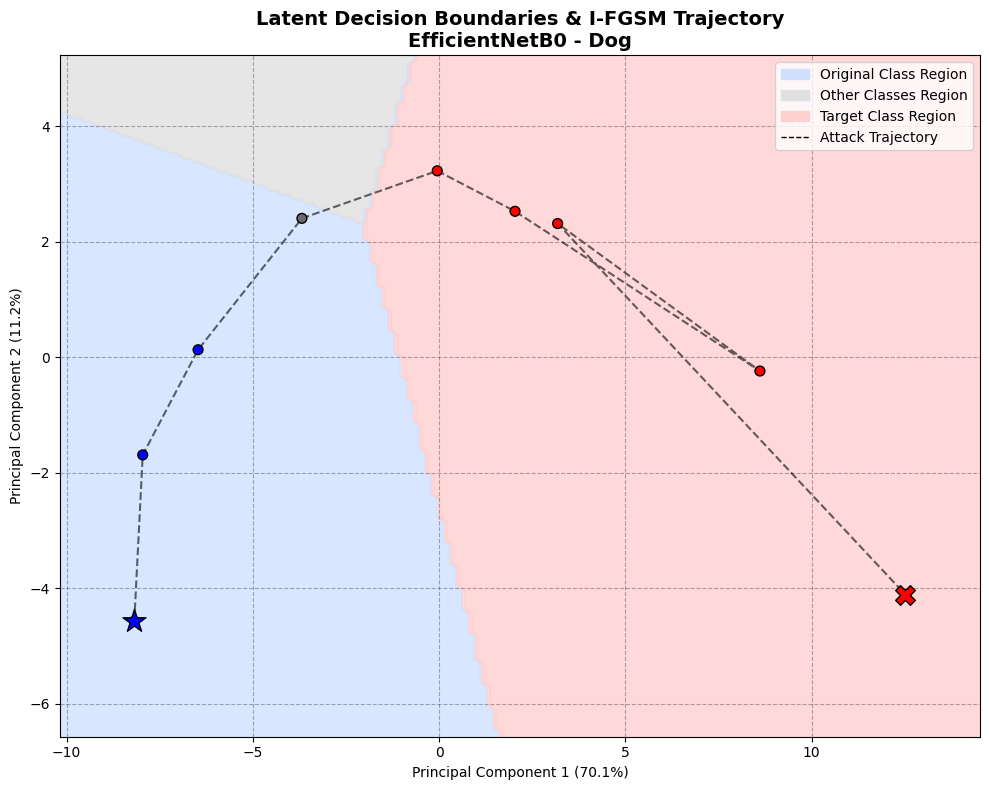

--- Processing Image: Lion ---


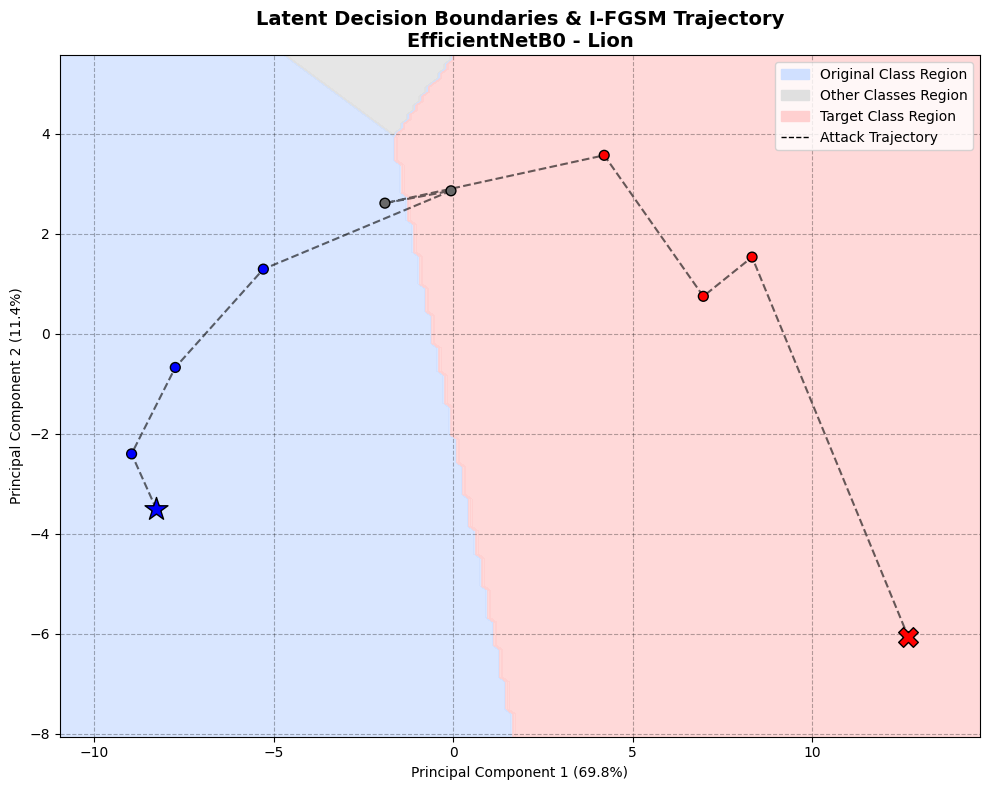


COMPUTING DECISION BOUNDARIES: InceptionV3

--- Processing Image: Dog ---


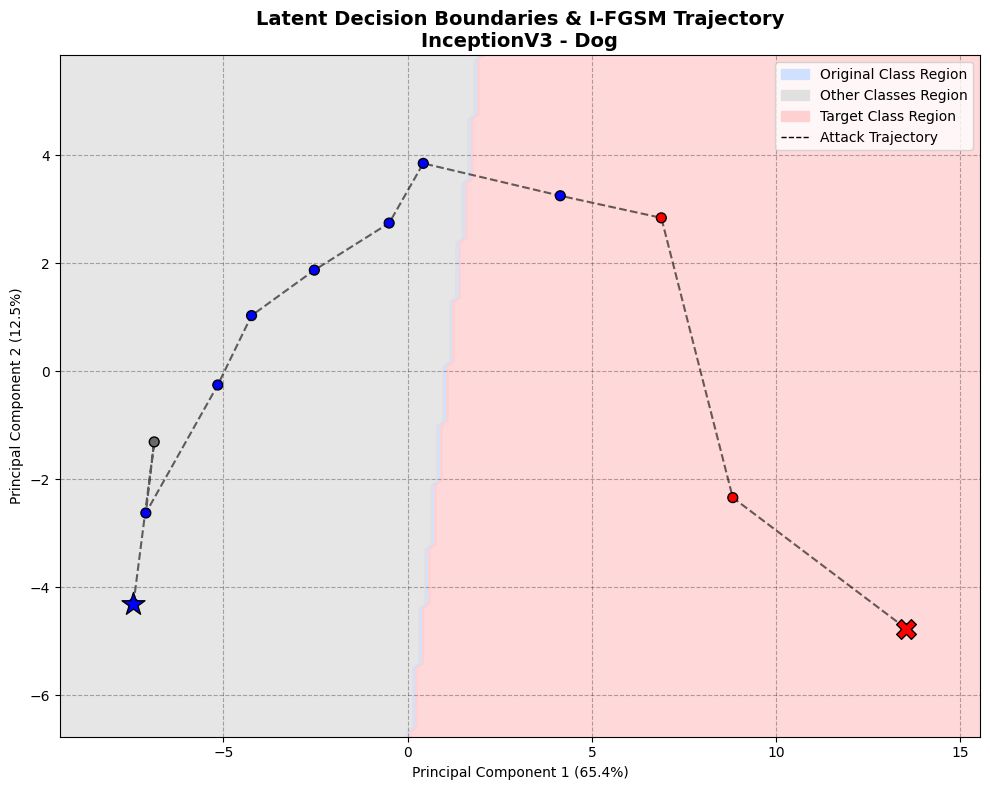

--- Processing Image: Lion ---


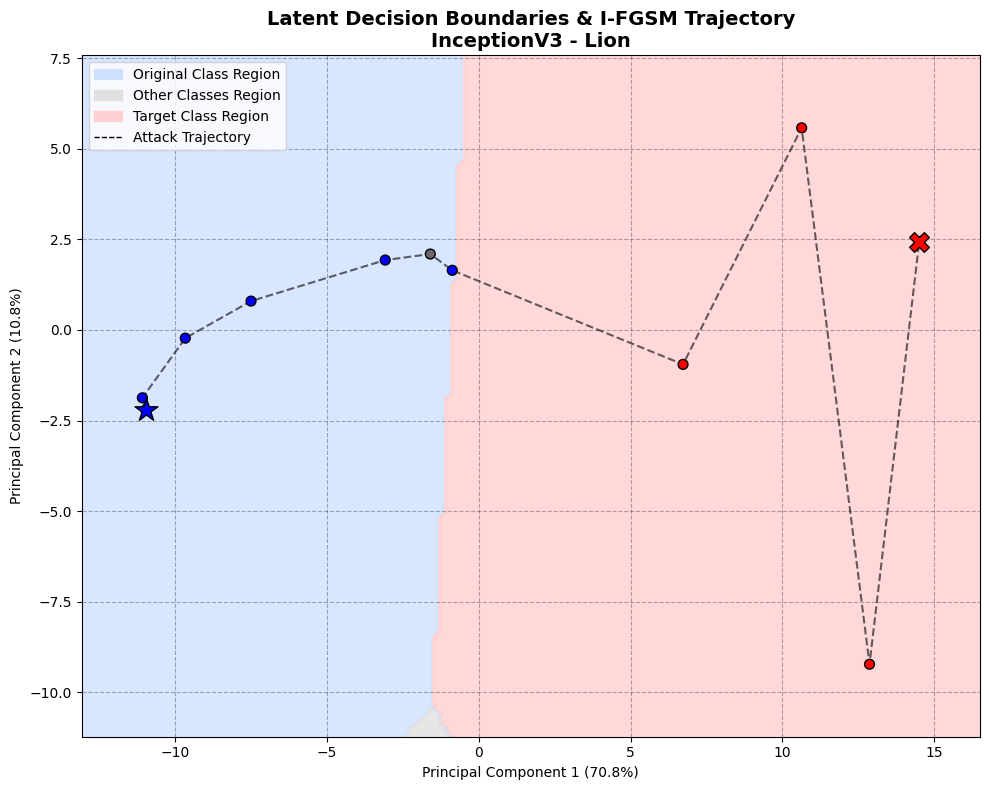

In [5]:
target_class_index = 301 # Ladybug
target_confidence = 0.95
max_iterations = 150
base_alpha = 0.01
grid_resolution = 150 # Determines the quality of the background contours (150x150 grid)

for model_name, m_config in models_dict.items():
    # Print a clear header when switching models
    print(f"\n{'='*80}")
    print(f"COMPUTING DECISION BOUNDARIES: {model_name}")
    print(f"{'='*80}\n")
    
    current_model = m_config['model']
    clip_min = m_config['clip_min']
    clip_max = m_config['clip_max']
    alpha = base_alpha * m_config['eps_scale']
    
    # Split model into Feature Extractor and Classifier
    feature_extractor = tf.keras.Model(inputs=current_model.input, outputs=current_model.layers[-1].input)
    classifier_layer = current_model.layers[-1] # The final Dense classification layer
    
    for img_name, img_path in images_dict.items():
        print(f"--- Processing Image: {img_name} ---")
        
        # Load Original Image
        input_img = load_and_preprocess_image(img_path, m_config['target_size'], m_config['preprocess_fn'])
        
        # Get Original Prediction and Label
        original_probs = current_model(input_img, training=False)
        original_class_idx = tf.argmax(original_probs, axis=-1).numpy()[0]
        
        # One-hot label for the target class (to calculate gradients towards it)
        target_label = tf.one_hot(target_class_index, original_probs.shape[-1])
        target_label = tf.reshape(target_label, (1, original_probs.shape[-1]))
        
        # Lists to store the trajectory data
        features_trajectory = []
        point_colors = []

        adv_image = tf.identity(input_img)
        
        # Targeted I-FGSM Attack Loop
        for i in range(max_iterations):
            # Extract current features and prediction using the fast __call__ method
            current_features = feature_extractor(adv_image, training=False)
            current_preds = current_model(adv_image, training=False)
            
            current_class_idx = tf.argmax(current_preds, axis=-1).numpy()[0]
            current_conf = current_preds[0, target_class_index].numpy()
            
            # Save features for PCA
            features_trajectory.append(current_features.numpy().flatten())
            
            # Determine color based on prediction
            if current_class_idx == original_class_idx:
                point_colors.append('blue') # Original Class
            elif current_class_idx == target_class_index:
                point_colors.append('red') # Target Class reached
            else:
                point_colors.append('dimgray') # Intermediate/Other Class
            
            # Stop if we reached the target confidence (optional, but good to avoid flatlining)
            if current_class_idx == target_class_index and current_conf >= target_confidence:
                break
            
            # Calculate gradients for the next step
            with tf.GradientTape() as tape:
                tape.watch(adv_image)
                prediction = current_model(adv_image, training=False)
                loss = loss_object(target_label, prediction)
                
            gradient = tape.gradient(loss, adv_image)
            signed_grad = tf.sign(gradient)
            
            # Step towards the target class
            adv_image = adv_image - alpha * signed_grad
            adv_image = tf.clip_by_value(adv_image, clip_min, clip_max)
            
        # PCA Transformation
        features_matrix = np.array(features_trajectory)
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(features_matrix)
        
        # Create 2D Grid for Decision Boundaries
        x_min, x_max = pca_result[:, 0].min() - 2, pca_result[:, 0].max() + 2
        y_min, y_max = pca_result[:, 1].min() - 2, pca_result[:, 1].max() + 2
        
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_resolution),
                             np.linspace(y_min, y_max, grid_resolution))
        
        # Inverse Transform and Predict Grid
        grid_2d = np.c_[xx.ravel(), yy.ravel()]
        grid_hd = pca.inverse_transform(grid_2d) # Project back to ~1280 dimensions
        
        # Feed the high-dimensional features directly into the final Dense layer
        grid_preds = classifier_layer(grid_hd)
        grid_classes = tf.argmax(grid_preds, axis=-1).numpy()
        
        # Map classes to our colormap values (0: Gray, 1: Blue, 2: Red)
        Z_colors = np.zeros_like(grid_classes)
        Z_colors[grid_classes == original_class_idx] = 1
        Z_colors[grid_classes == target_class_index] = 2
        Z = Z_colors.reshape(xx.shape)
        
        # Plotting
        plt.figure(figsize=(10, 8))
        
        # Plot Decision Boundaries
        plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.8)
        
        # Plot Trajectory over the boundaries
        plt.plot(pca_result[:, 0], pca_result[:, 1], 'k--', alpha=0.6, label='Gradient Path')
        plt.scatter(pca_result[:, 0], pca_result[:, 1], c=point_colors, s=50, edgecolors='black', zorder=5)
        
        # Start and End points
        plt.scatter(pca_result[0, 0], pca_result[0, 1], c=point_colors[0], marker='*', s=300, edgecolors='black', label='Start', zorder=10)
        plt.scatter(pca_result[-1, 0], pca_result[-1, 1], c=point_colors[-1], marker='X', s=200, edgecolors='black', label='End', zorder=10)
        
        plt.title(f'Latent Decision Boundaries & I-FGSM Trajectory\n{model_name} - {img_name}', fontsize=14, fontweight='bold')
        plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        
        # Custom Legend
        legend_elements = [
            mpatches.Patch(color='#D0E0FF', label='Original Class Region'),
            mpatches.Patch(color='#E0E0E0', label='Other Classes Region'),
            mpatches.Patch(color='#FFD0D0', label='Target Class Region'),
            Line2D([0], [0], color='k', lw=1, ls='--', label='Attack Trajectory')
        ]
        plt.legend(handles=legend_elements, loc='best')
        plt.grid(True, linestyle='--', alpha=0.3, color='black')
        
        plt.tight_layout()
        plt.show()